<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/simulation/vkernel_text_to_field_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# V-KERNEL TEXT TO FIELD DEMO
# text/code -> 6D state -> graph field -> convergence -> mode

In [1]:
!pip install numpy matplotlib networkx

import math
import re
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
STATE_KEYS = [
    "red_mass",
    "orange_flow",
    "yellow_struct",
    "green_balance",
    "blue_law",
    "violet_future",
]

def normalize_state(v):
    total = sum(max(v[k], 0.0) for k in v)
    if total <= 1e-9:
        return {k: 1.0 / len(v) for k in v}
    return {k: max(v[k], 0.0) / total for k in v}


def looks_like_code(text):
    code_signals = [
        r"\bdef\b", r"\bclass\b", r"\bif\b", r"\bfor\b", r"\bwhile\b",
        r"\breturn\b", r"\btry\b", r"\bexcept\b", r"\bimport\b",
        r"[{}():=]", r"\bpass\b"
    ]
    hits = sum(bool(re.search(p, text)) for p in code_signals)
    return hits >= 2


def encode_text_to_state(text):
    text_lower = text.lower()

    v = {
        "red_mass": 0.15,
        "orange_flow": 0.15,
        "yellow_struct": 0.15,
        "green_balance": 0.15,
        "blue_law": 0.15,
        "violet_future": 0.15,
    }

    if any(w in text_lower for w in ["error", "fail", "failing", "problem", "unstable", "conflict"]):
        v["red_mass"] += 0.18

    if any(w in text_lower for w in ["loop", "stuck", "deadlock", "blocked"]):
        v["red_mass"] += 0.12
        v["orange_flow"] -= 0.06

    if any(w in text_lower for w in ["adapt", "retry", "move", "explore", "flexibility", "alternative"]):
        v["orange_flow"] += 0.18

    if any(w in text_lower for w in ["plan", "structure", "step", "define", "organize"]):
        v["yellow_struct"] += 0.18

    if any(w in text_lower for w in ["but", "while", "however", "balance", "integrate"]):
        v["green_balance"] += 0.18

    if any(w in text_lower for w in ["rule", "constraint", "validate", "formal", "strict"]):
        v["blue_law"] += 0.18

    if any(w in text_lower for w in ["future", "potential", "next", "change", "transition"]):
        v["violet_future"] += 0.18

    if looks_like_code(text):
        if any(tok in text for tok in ["def ", "class ", "return", "if ", "for ", "while ", "try:", "except", "import "]):
            v["blue_law"] += 0.14
            v["yellow_struct"] += 0.08

        if "return" in text_lower:
            v["yellow_struct"] += 0.06
            v["green_balance"] += 0.04

        if re.search(r"\bfor\b", text_lower):
            v["orange_flow"] += 0.04

        if re.search(r"while\s+true\s*:", text_lower):
            v["red_mass"] += 0.25
            v["orange_flow"] -= 0.12
            v["green_balance"] -= 0.10

        if re.search(r"\bpass\b", text_lower):
            v["orange_flow"] -= 0.10
            v["yellow_struct"] -= 0.02
            v["red_mass"] += 0.05

        if re.search(r"except\s*:", text_lower):
            v["red_mass"] += 0.12
            v["blue_law"] -= 0.05
            v["green_balance"] -= 0.05

    return normalize_state(v)

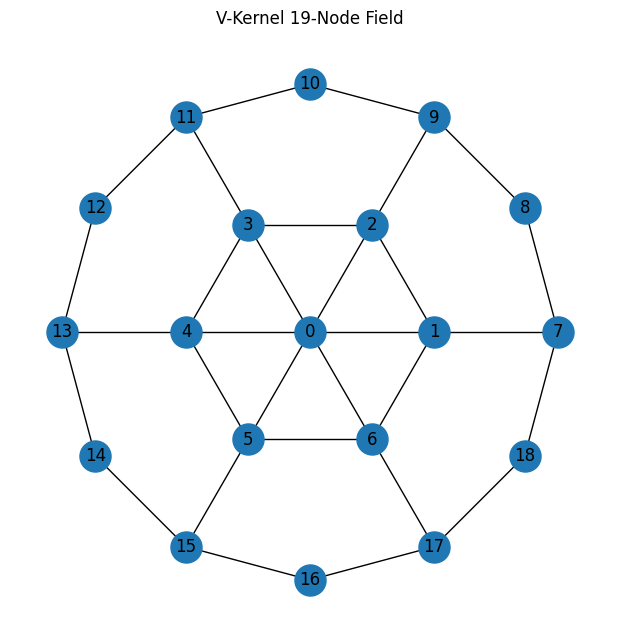

In [3]:
def generate_hex_positions():
    positions = {}
    idx = 0

    positions[idx] = (0.0, 0.0)
    idx += 1

    r1 = 1.0
    for k in range(6):
        angle = 2 * math.pi * k / 6
        positions[idx] = (r1 * math.cos(angle), r1 * math.sin(angle))
        idx += 1

    r2 = 2.0
    for k in range(12):
        angle = 2 * math.pi * k / 12
        positions[idx] = (r2 * math.cos(angle), r2 * math.sin(angle))
        idx += 1

    return positions


def build_graph():
    pos = generate_hex_positions()
    G = nx.Graph()

    for n, p in pos.items():
        G.add_node(n, pos=p)

    nodes = list(G.nodes())
    for i in nodes:
        xi, yi = G.nodes[i]["pos"]
        for j in nodes:
            if i >= j:
                continue
            xj, yj = G.nodes[j]["pos"]
            d = math.dist((xi, yi), (xj, yj))
            if d <= 1.18:
                G.add_edge(i, j, weight=1.0)

    return G


G = build_graph()
pos = nx.get_node_attributes(G, "pos")
N = len(G.nodes())

plt.figure(figsize=(6,6))
nx.draw(G, pos, with_labels=True, node_size=500)
plt.title("V-Kernel 19-Node Field")
plt.axis("equal")
plt.show()

In [4]:
STATE_TO_NODES = {
    "red_mass": [0, 1, 2],
    "orange_flow": [3, 4, 5],
    "yellow_struct": [6, 7, 8],
    "green_balance": [9, 10, 11],
    "blue_law": [12, 13, 14],
    "violet_future": [15, 16, 17, 18],
}

def state_to_graph_signal(state):
    z = np.zeros(N, dtype=float)

    for key, nodes in STATE_TO_NODES.items():
        value = state[key]
        for node in nodes:
            z[node] += value

    z = z / (np.max(np.abs(z)) + 1e-8)
    return z

In [5]:
A = nx.to_numpy_array(G, weight="weight", dtype=float)
D = np.diag(A.sum(axis=1))
L = D - A

eigvals, eigvecs = np.linalg.eigh(L)

def normalize(x):
    return x / (np.max(np.abs(x)) + 1e-8)

def mode_coefficients(x):
    return eigvecs.T @ x

def project_to_modes(x, keep=8):
    coeffs = mode_coefficients(x)
    filtered = np.zeros_like(coeffs)
    filtered[:keep] = coeffs[:keep]
    return eigvecs @ filtered

def evolve_field(z0, steps=40, alpha=0.18, beta=0.06, gamma=0.72, keep=8):
    z = normalize(z0)
    prev = z.copy()

    trajectory = [z.copy()]
    coeff_history = [np.abs(mode_coefficients(z))]

    for _ in range(steps):
        diffusion = -(L @ z)
        projected = project_to_modes(z, keep=keep)
        damping = z ** 3

        new_z = (
            gamma * z
            + alpha * diffusion
            + 0.18 * projected
            - beta * damping
            + 0.04 * prev
        )

        prev = z.copy()
        z = normalize(new_z)

        trajectory.append(z.copy())
        coeff_history.append(np.abs(mode_coefficients(z)))

    return np.array(trajectory), np.array(coeff_history)

In [6]:
xs = np.array([pos[i][0] for i in G.nodes()])
ys = np.array([pos[i][1] for i in G.nodes()])

gx = np.linspace(xs.min() - 0.7, xs.max() + 0.7, 250)
gy = np.linspace(ys.min() - 0.7, ys.max() + 0.7, 250)
XX, YY = np.meshgrid(gx, gy)

def smooth_field(values, sigma=0.40):
    ZZ = np.zeros_like(XX, dtype=float)
    for x0, y0, v in zip(xs, ys, values):
        ZZ += v * np.exp(-((XX - x0)**2 + (YY - y0)**2) / (2 * sigma**2))
    return ZZ


def plot_field(values, title):
    ZZ = smooth_field(values)

    plt.figure(figsize=(7,7))
    plt.contourf(XX, YY, ZZ, levels=60, cmap="seismic", alpha=0.92)
    plt.contour(XX, YY, ZZ, levels=[0], colors="white", linewidths=1.6)
    nx.draw_networkx_edges(G, pos, edge_color="white", alpha=0.18)
    plt.scatter(xs, ys, c="black", s=18)
    plt.title(title)
    plt.axis("equal")
    plt.axis("off")
    plt.show()

In [7]:
examples = {
    "Balanced text": "We should reduce instability but keep flexibility and adapt the plan.",
    "Unstable text": "The system is failing, unstable, and stuck in a loop with errors.",
    "Good code": """
def process(data):
    if not data:
        return None
    for item in data:
        handle(item)
    return True
""",
    "Bad loop": """
while True:
    pass
""",
    "Bare except": """
try:
    risky_action()
except:
    pass
""",
}

results = {}

for name, text in examples.items():
    state = encode_text_to_state(text)
    z0 = state_to_graph_signal(state)
    trajectory, coeff_history = evolve_field(z0)

    final_state = trajectory[-1]
    final_coeffs = np.abs(mode_coefficients(final_state))
    dominant_mode = int(np.argmax(final_coeffs[1:10]) + 1)

    results[name] = {
        "text": text,
        "state": state,
        "z0": z0,
        "trajectory": trajectory,
        "coeff_history": coeff_history,
        "final_state": final_state,
        "dominant_mode": dominant_mode,
        "final_coeffs": final_coeffs,
    }

    print("\n===", name, "===")
    print("6D state:")
    for k, v in state.items():
        print(f"{k:15}: {v:.3f}")
    print("Dominant mode:", dominant_mode)


=== Balanced text ===
6D state:
red_mass       : 0.104
orange_flow    : 0.229
yellow_struct  : 0.229
green_balance  : 0.229
blue_law       : 0.104
violet_future  : 0.104
Dominant mode: 2

=== Unstable text ===
6D state:
red_mass       : 0.395
orange_flow    : 0.079
yellow_struct  : 0.132
green_balance  : 0.132
blue_law       : 0.132
violet_future  : 0.132
Dominant mode: 1

=== Good code ===
6D state:
red_mass       : 0.119
orange_flow    : 0.151
yellow_struct  : 0.230
green_balance  : 0.151
blue_law       : 0.230
violet_future  : 0.119
Dominant mode: 1

=== Bad loop ===
6D state:
red_mass       : 0.338
orange_flow    : 0.000
yellow_struct  : 0.158
green_balance  : 0.173
blue_law       : 0.218
violet_future  : 0.113
Dominant mode: 2

=== Bare except ===
6D state:
red_mass       : 0.299
orange_flow    : 0.047
yellow_struct  : 0.196
green_balance  : 0.093
blue_law       : 0.224
violet_future  : 0.140
Dominant mode: 3


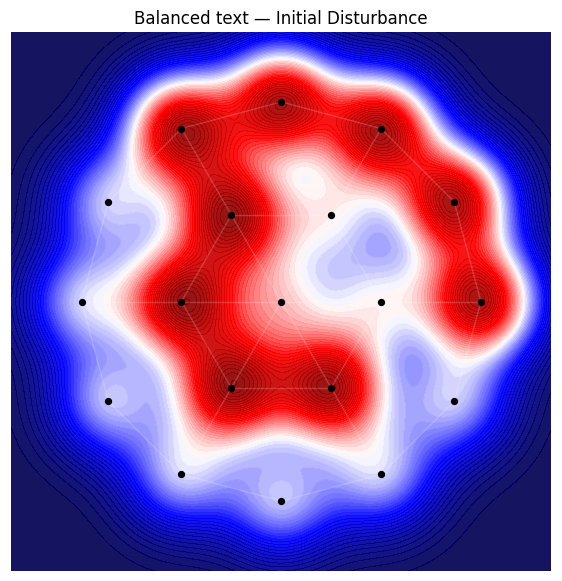

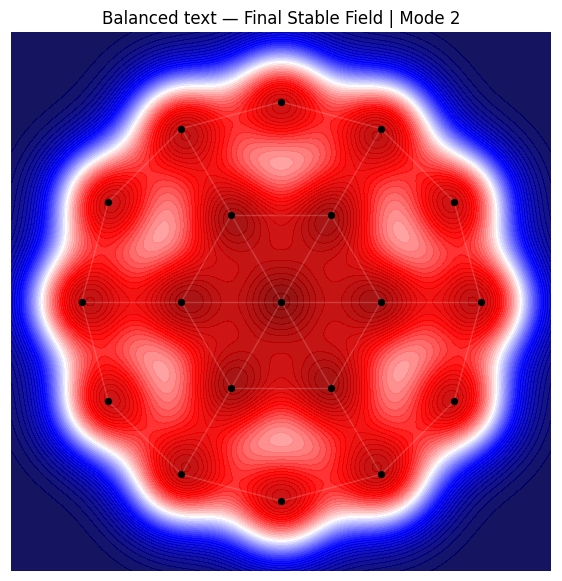

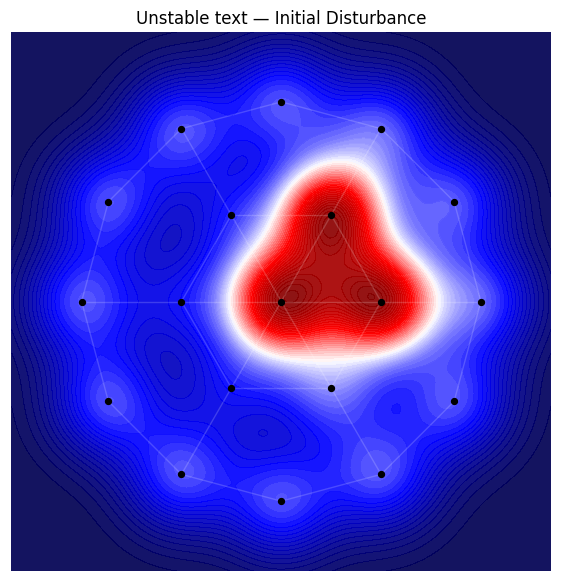

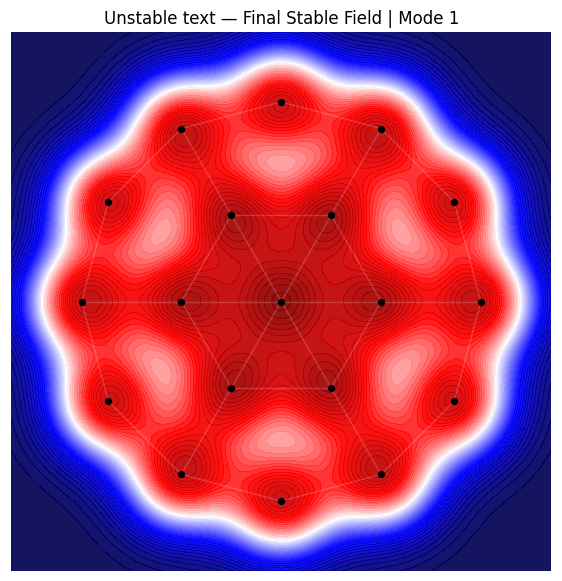

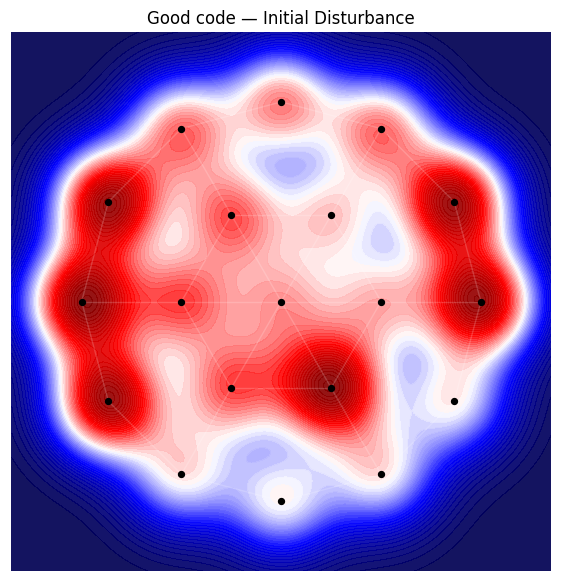

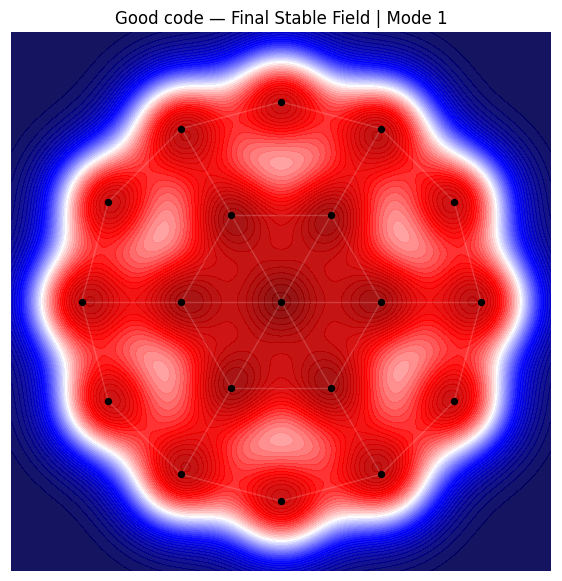

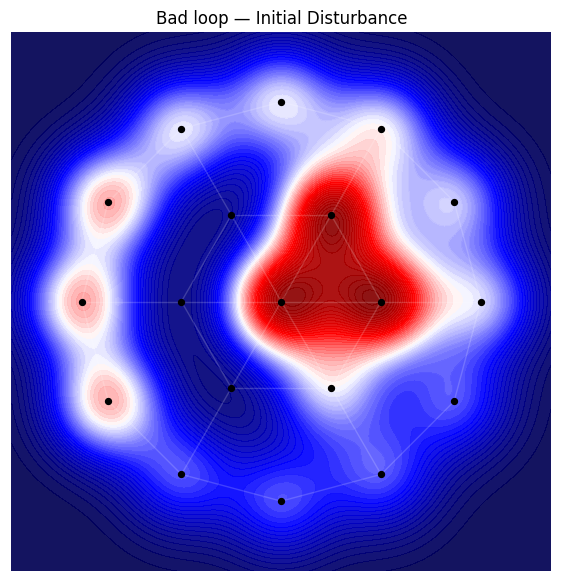

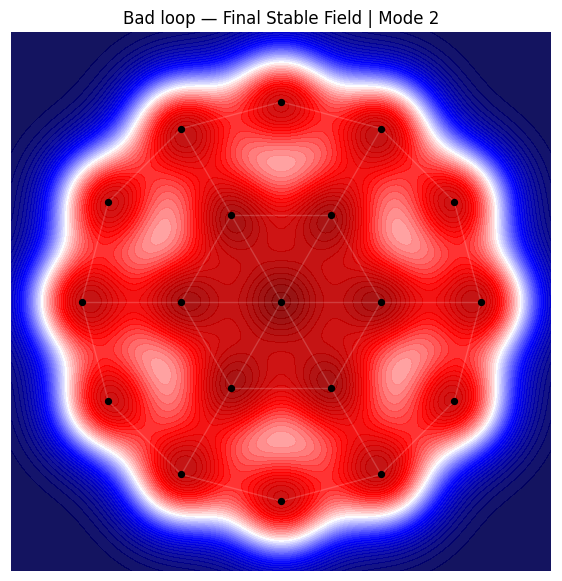

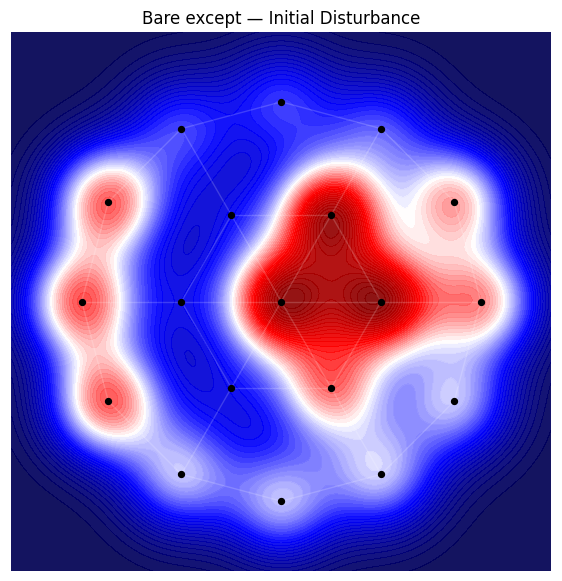

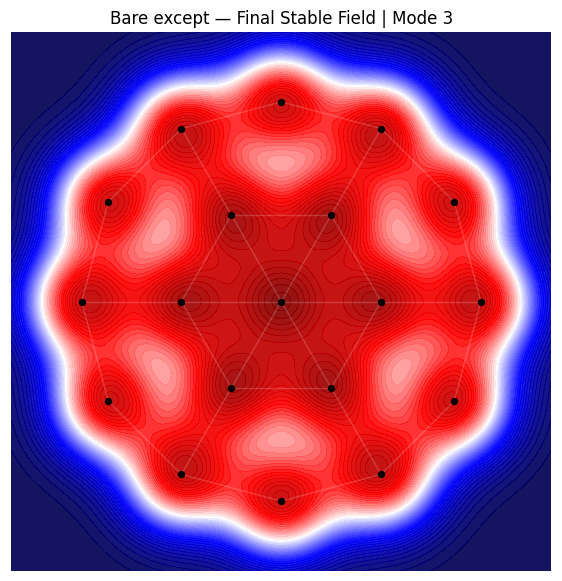

In [8]:
for name, data in results.items():
    plot_field(data["z0"], f"{name} — Initial Disturbance")
    plot_field(data["final_state"], f"{name} — Final Stable Field | Mode {data['dominant_mode']}")

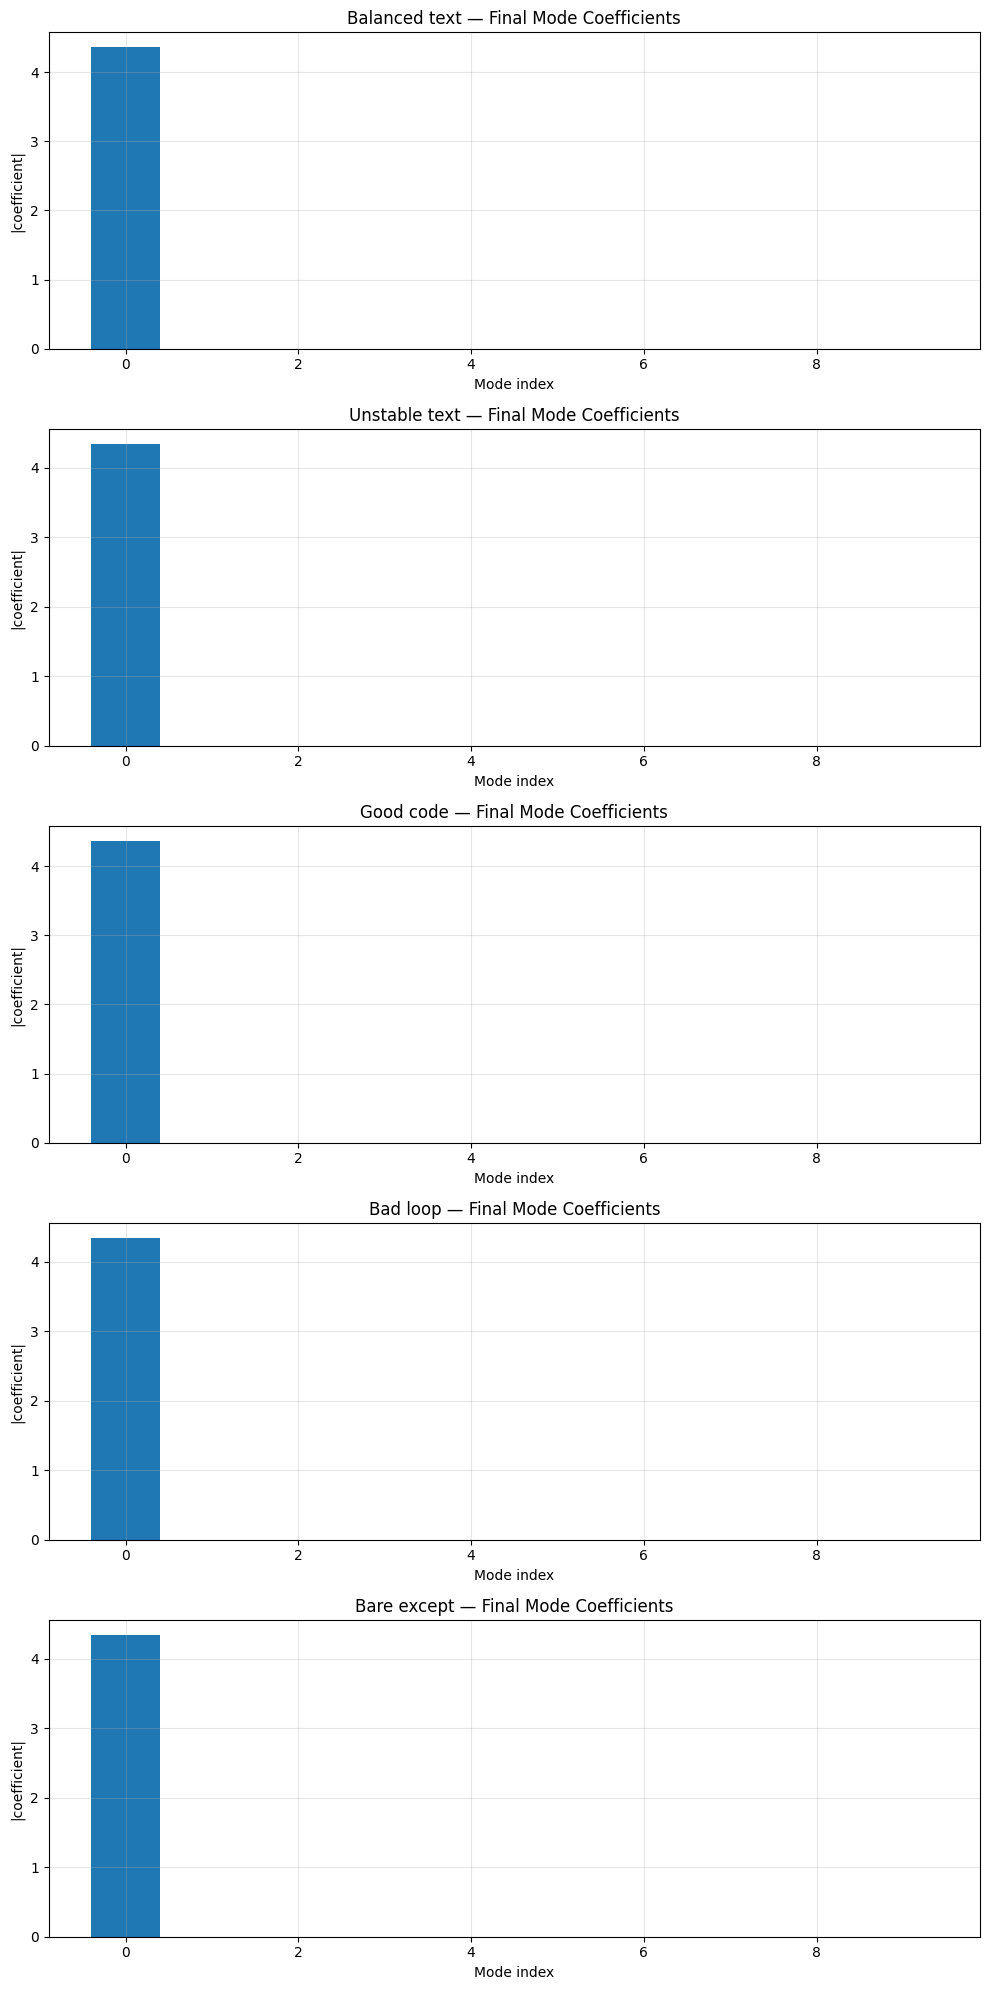

In [9]:
fig, axes = plt.subplots(len(results), 1, figsize=(10, 4 * len(results)))

if len(results) == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, results.items()):
    coeffs = data["final_coeffs"]
    ax.bar(range(10), coeffs[:10])
    ax.set_title(f"{name} — Final Mode Coefficients")
    ax.set_xlabel("Mode index")
    ax.set_ylabel("|coefficient|")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

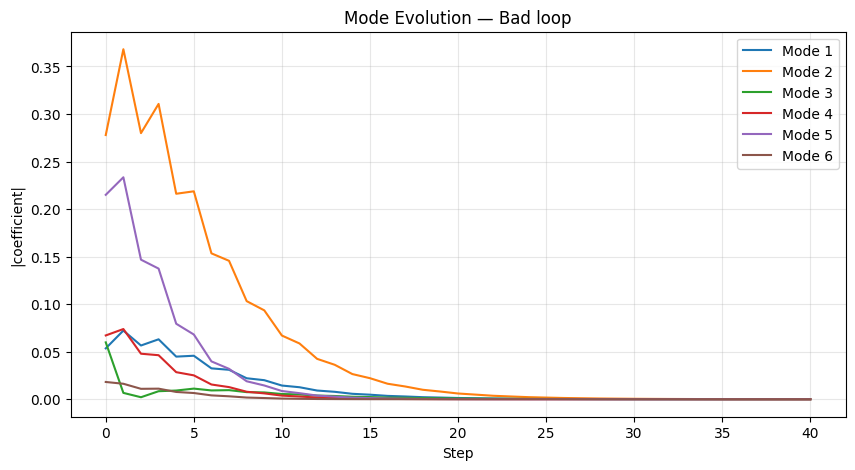

In [10]:
selected = "Bad loop"
data = results[selected]

plt.figure(figsize=(10,5))
for k in range(1, 7):
    plt.plot(data["coeff_history"][:, k], label=f"Mode {k}")

plt.title(f"Mode Evolution — {selected}")
plt.xlabel("Step")
plt.ylabel("|coefficient|")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
print("=== TEXT/CODE → FIELD → MODE SUMMARY ===")

for name, data in results.items():
    print(f"{name:15} -> Mode {data['dominant_mode']}")

=== TEXT/CODE → FIELD → MODE SUMMARY ===
Balanced text   -> Mode 2
Unstable text   -> Mode 1
Good code       -> Mode 1
Bad loop        -> Mode 2
Bare except     -> Mode 3
